In [10]:
# 🐍 python!

print("hello world!")
name = "Sardor"
print(f"Hello {name}")

hello world!
Hello Sardor


In [12]:
myNumber = 5
print(myNumber + 10)
print(myNumber * 10)
print(myNumber // 10)

# add a line that performs another computation
# on myNumber, and print it

15
50
0


In [13]:
# import libraries: matplotlib and pandas

from matplotlib import pyplot as plt
import pandas as pd

# setup for seeing graphs in notebook
%matplotlib inline
# more on what above line means:
# https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html#Plotting-from-an-IPython-notebook

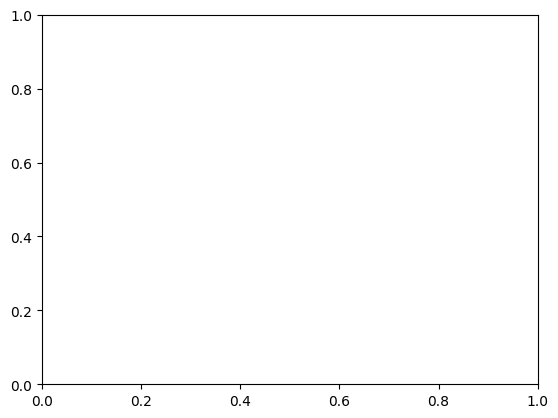

In [14]:
# start with a figure ...
# when we write plt.something(), the "." dot allows us to call any of the functions bundled up in plt
# full list here in documentation: https://matplotlib.org/stable/api/pyplot_summary.html

fig = plt.figure()
ax = plt.axes()
plt.show()

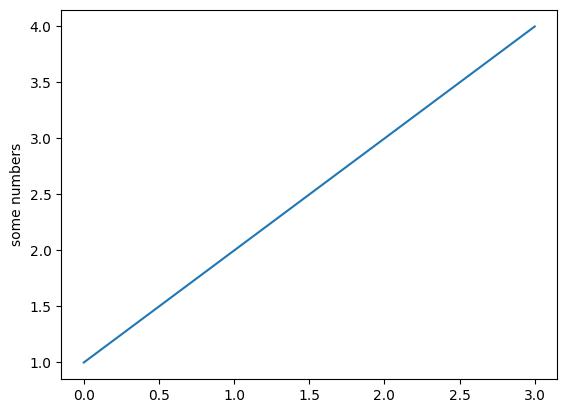

In [4]:
# warm-up
# make a most basic line plot

plt.plot([1, 2, 3, 4])
# square brackets [x, y, z] make arrays
# each element in array is separated by a "," comma

# write in comments here: what are the (x,y) values of the resulting points?
# x is the Y values and the array indices are actually X values


plt.ylabel('some numbers')
# giving my y-axis a label

plt.xlabel('array indices')

plt.show()

# now: add a line that gives the x-axis a label
# where do you need to add this line?
# before the plt.show()

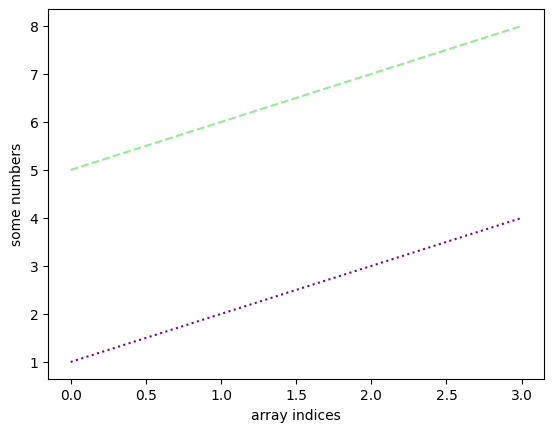

In [20]:
# change the color, linestyle, other options
# by adding parameters in the parantheses
# plt.plot(data, options)

plt.plot([1, 2, 3, 4], color="purple", linestyle="dotted")
# all options available, documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
# (look for section "other parameters" in docs)

plt.ylabel('some numbers')
# giving my y-axis a label

plt.xlabel('array indices')

plt.plot([5, 6, 7, 8], color="lightgreen", linestyle="--")

plt.show()

# add a line of code that adds a label to the x-axis
# and adds another line with [5, 6, 7, 8], with different color + line style

In [29]:
# warm-up
# what happens in this code?
x = range(0, 25)

import random
y = []
for i in range(0,25):
    y.append(random.randint(1,30))

print(y)

[16, 28, 30, 14, 26, 7, 28, 16, 30, 23, 4, 10, 8, 20, 17, 4, 8, 5, 18, 25, 26, 6, 26, 2, 14]


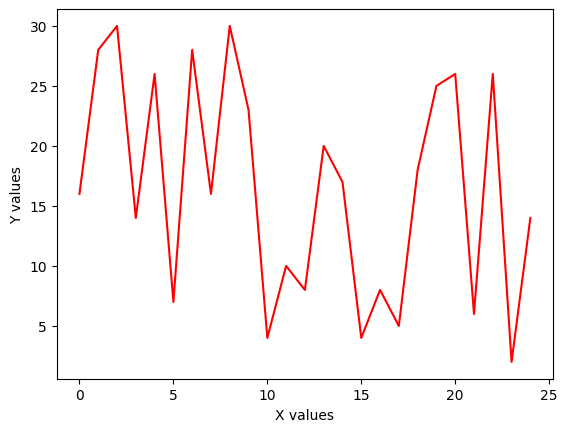

In [32]:
# now ... how would you plot the values in the array called y in the previous cell?
# make it a line plot with the line color as red
plt.plot(x, y, color="red")
plt.xlabel("X values")
plt.ylabel("Y values")

plt.show()

In [33]:
# returning to john snow + cholera ...
# let's load data from a file

cholera_dates_df = pd.read_csv('https://raw.githubusercontent.com/mab253/dataviz_fall24/main/week1/snow-data.csv')

# df here stands for "DataFrame" - basically a table organized with columns
# 🐼 remember pd = pandas, and "." dot lets us use function "read_csv"

# show the first 5 items from data
cholera_dates_df.head(5)

# show the first x items from data: df.head(x)

,order,date,attacks,deaths
0,1,1854-08-19,1,1
1,2,1854-08-20,1,0
2,3,1854-08-21,1,2
3,4,1854-08-22,0,0
4,5,1854-08-23,1,0


In [34]:
# show the last 2 items from data
cholera_dates_df.tail(2)

,order,date,attacks,deaths
41,42,1854-09-29,0,1
42,43,1854-09-30,0,0


Text(0, 0.5, 'Death & Case count')

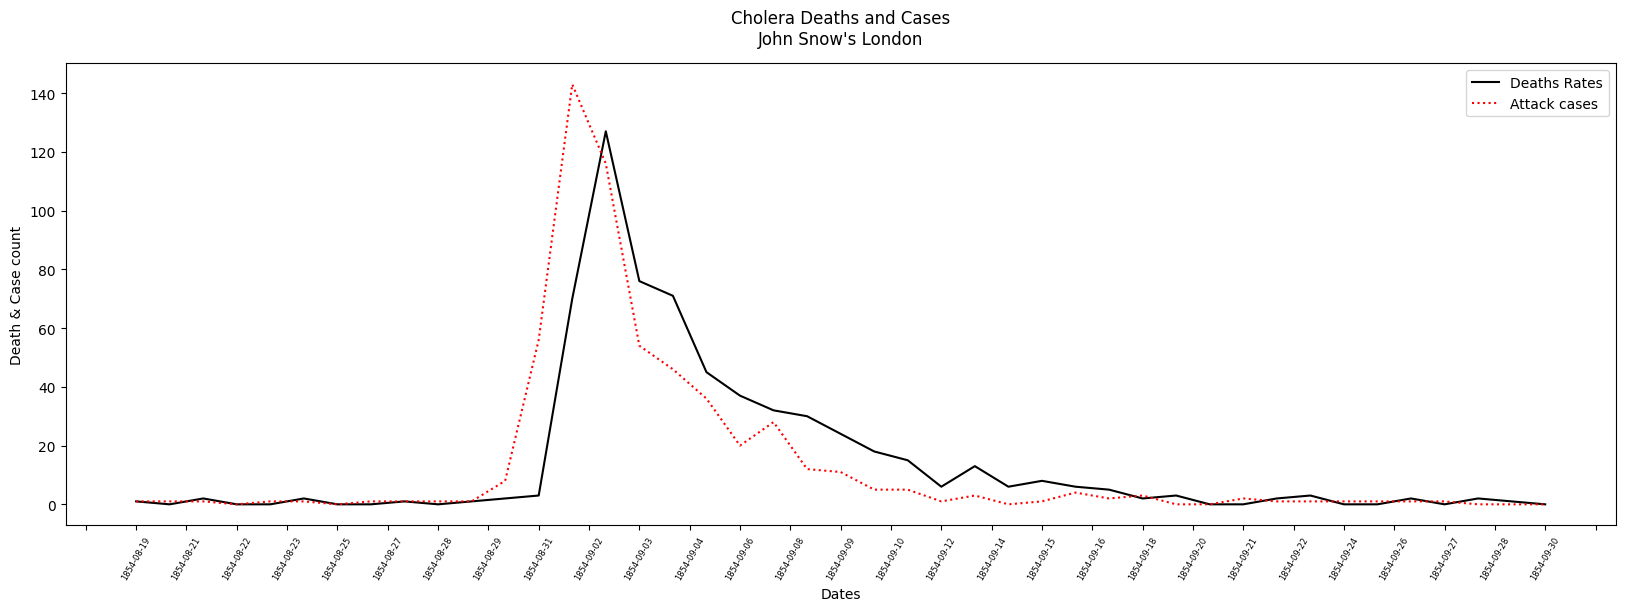

In [74]:
# make a line plot with "deaths" data

plt.figure(figsize=(20,6))
deaths_line = plt.plot(cholera_dates_df.date, cholera_dates_df.deaths, color="black", linestyle="-", label="Deaths Rates")
# the first 2 values are the x and y axis data - look what matches the column names from the dataframe! (df.columnName)

# 😱 x-axis is a mess!!
# let's start to design the x-axis elements ...
plt.tick_params(axis='x', labelrotation=60, labelsize=6)
# all the options for tick_params() function: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tick_params.html

# let's make the x-axis better ...
# by cleaning up the number of "ticks" shown

from matplotlib import ticker
# pull more code from matplotlib, the "ticker" object

# maxTicks = 6
maxTicks = len(cholera_dates_df) // 1.2

xticks = ticker.MaxNLocator(maxTicks)

# set the xaxis number of ticks
# gca() is a function: "get current axis"
plt.gca().xaxis.set_major_locator(xticks)

# instead of a hard-coded number, what about every-other row, every other date?
# maxTicks = len(cholera_dates_df) / 2
# len here returns the length of the DataFrame, how many rows we have




# add a legend
# more documentation on legend: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

plt.title('Cholera Deaths and Cases\nJohn Snow\'s London', pad=14, loc='center')
# add a title
# more documentation on titles: https://matplotlib.org/stable/gallery/text_labels_and_annotations/titles_demo.html#sphx-glr-gallery-text-labels-and-annotations-titles-demo-py

# let's add "cases" data! add another line to the plot, with unique color and line style

cases_line = plt.plot(cholera_dates_df.date, cholera_dates_df.attacks, color="red", label="Attack cases", linestyle=":")
plt.legend(loc="best", bbox_to_anchor=(0.5, 0., 0.5, 0.5))
# we should label our axes!

# how do we fix the legend here?
plt.legend()
plt.xlabel("Dates")
plt.ylabel("Death & Case count")


In [72]:
# let's work with scatter plot data, also from John Snow's Ghost Map

cholera_deaths_df = pd.read_csv('https://raw.githubusercontent.com/yy/dviz-course/master/data/deaths.csv')

# let's look @ the first 20 rows of this DataFrame
cholera_deaths_df.head(20)

,X,Y
0,13.588010,11.095600
1,9.878124,12.559180
2,14.653980,10.180440
3,15.220570,9.993003
4,13.162650,12.963190
5,13.806170,8.889046
6,13.102140,10.560810
7,11.004030,11.867130
8,15.154750,11.704510
9,11.126390,9.643859


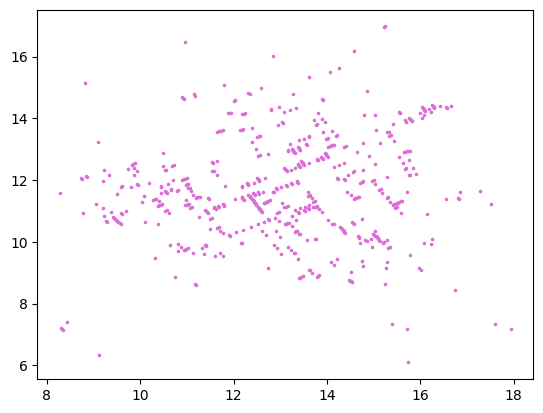

In [76]:
# now we'll plot these points
# documentation on scatter function: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

plt.scatter(cholera_deaths_df.X, cholera_deaths_df.Y, color="orchid", s=2.5)
# the first value there is the x-axis data - dataframe.columnName
# the second value is the y-axis data - dataframe.columnName
# s there refers to size - 1 = 1/72 inches! (in documentation)

# what color should we choose? full list: https://matplotlib.org/stable/gallery/color/named_colors.html
# other ways to name colors, more detail: https://matplotlib.org/stable/tutorials/colors/colors.html
# RGB, HEX, other color systems you may know - these work!

In [77]:
# let's also load the location of the water PUMPS (optimized for this exercise)

cholera_pumps_df = pd.read_csv('https://raw.githubusercontent.com/yy/dviz-course/master/data/pumps.csv')

# double check what the pump data looks like

cholera_pumps_df.head()

,X,Y
0,8.651201,17.891600
1,10.984780,18.517851
2,13.378190,17.394541
3,14.879830,17.809919
4,8.694768,14.905470


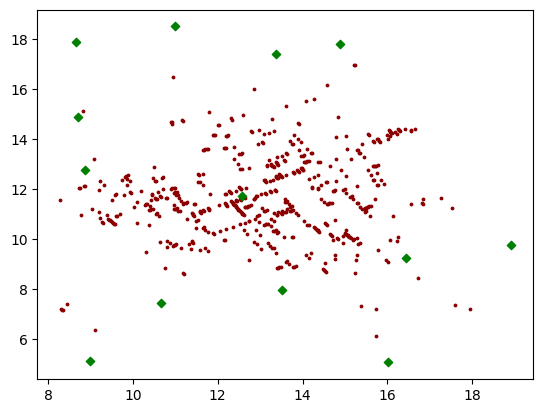

In [89]:
# and now let's plot them both!
plt.scatter(cholera_deaths_df.X, cholera_deaths_df.Y, color="darkred", s=3)
plt.scatter(cholera_pumps_df.X, cholera_pumps_df.Y, color="green", s=18, marker="D")
# add code here

# what channels can we change to "pop-out" the information, the pump with the most deaths clustered around?

In [90]:
# we can also save the image

# plt.savefig("snow.png")

# higher resolution? matplotlib thinks in "inches" ...
fig = plt.gcf()
# gcf() = get current figure
# print(fig.get_size_inches())
# what size is the graph, in inches?
# now choose some parameters
# dpi = dots per inch, pixels
plt.savefig("snow.png", dpi=400, format='png', bbox_inches='tight', pad_inches=0.1)

<Figure size 640x480 with 0 Axes>

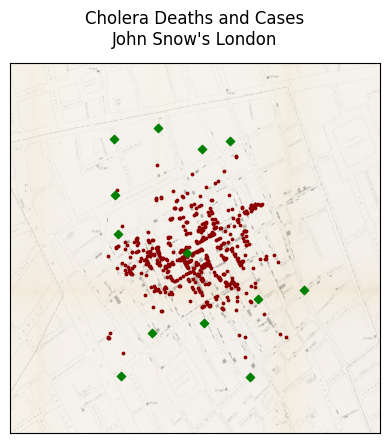

In [92]:
# what if we wanted to put a map of London behind this translated geospatial data?!

# use python image library
from PIL import Image

# load the image
# first download it from here:
# https://github.com/mab253/dataviz_fall24/tree/main/week1 - the image snow-map-bg.png
# then add it to the google colab (temp) file system

image_path = "/content/snow-map-bg.png"
img = Image.open(image_path)

# place the image on the figure, based on min/max x and y points
# like stretching across a canvas
plt.imshow(img, extent=[3, 23, 2, 22], alpha=0.5)
# alpha = opacity value; < 1 is less than opaque
# so the data can show up "on top" (gestalt!)

# add scatter plots for deaths and pumps, data
plt.scatter(cholera_deaths_df.X, cholera_deaths_df.Y, color="darkred", s=3)
plt.scatter(cholera_pumps_df.X, cholera_pumps_df.Y, color="green", s=18, marker="D")

# let's hide the axes labels - they don't really represent the geospatial data here
plt.xticks([])  # hide x-axis tick labels
plt.yticks([])  # hide y-axis tick labels

# add a title here before you save!
plt.title('Cholera Deaths and Cases\nJohn Snow\'s London', pad=14, loc='center')

# high-res download of the figure
plt.savefig("snow-map.png", dpi=300, format='png', bbox_inches='tight', pad_inches=0.1)

## 🪼 when you are finished! submit: 🖇️

1. Download this notebook as an `.ipynb` file (File -> Download)
2. Go to [this link](https://airtable.com/app6HibgdChLzfvNP/shrYWYvDm5Eviq8bY) and upload the file via the form.
3. Then you're done! In-class labs are counted as participation credit.

**🗺️📄 citations:**

- John Snow dates data from: https://github.com/shukkkur/John-Snows-Ghost-Map/tree/main/datasets ([Datacamp](https://www.datacamp.com/))
- John Snow deaths + pump data from: https://yyahn.com/dviz-course/m02-history/lab02/ (Yong-Yeol Ahn)
- original John Snow map image: _A map taken from a report by Dr. John Snow._ [Wellcome Collection](https://wellcomecollection.org/works/uxgfjt62/items).